In [63]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
from pymc_marketing.metrics import crps

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The jaxtyping extension is already loaded. To reload it, use:
  %reload_ext jaxtyping


In [75]:
seed: int = 42
rng: np.random.Generator = np.random.default_rng(seed=seed)

n = 50

y_true = rng.normal(0, 1, size=n)

draws = 1_000
k = 21

mus = np.linspace(-10, 10, k)
sigmas = np.linspace(0.1, 10, k)

noise = rng.normal(0, 1, size=(1, draws, n))

sigma = sigmas[np.newaxis, np.newaxis, :] * noise[..., np.newaxis]

y_pred_array = (
    y_true[np.newaxis, np.newaxis, :, np.newaxis, np.newaxis]
    + mus[np.newaxis, np.newaxis, np.newaxis, np.newaxis, :]
    + sigma[..., np.newaxis]
)

y_pred = xr.DataArray(
    y_pred_array,
    coords=([0], np.arange(draws), np.arange(n), sigmas, mus),
    dims=["chain", "draw", "n", "sigma", "mu"],
)

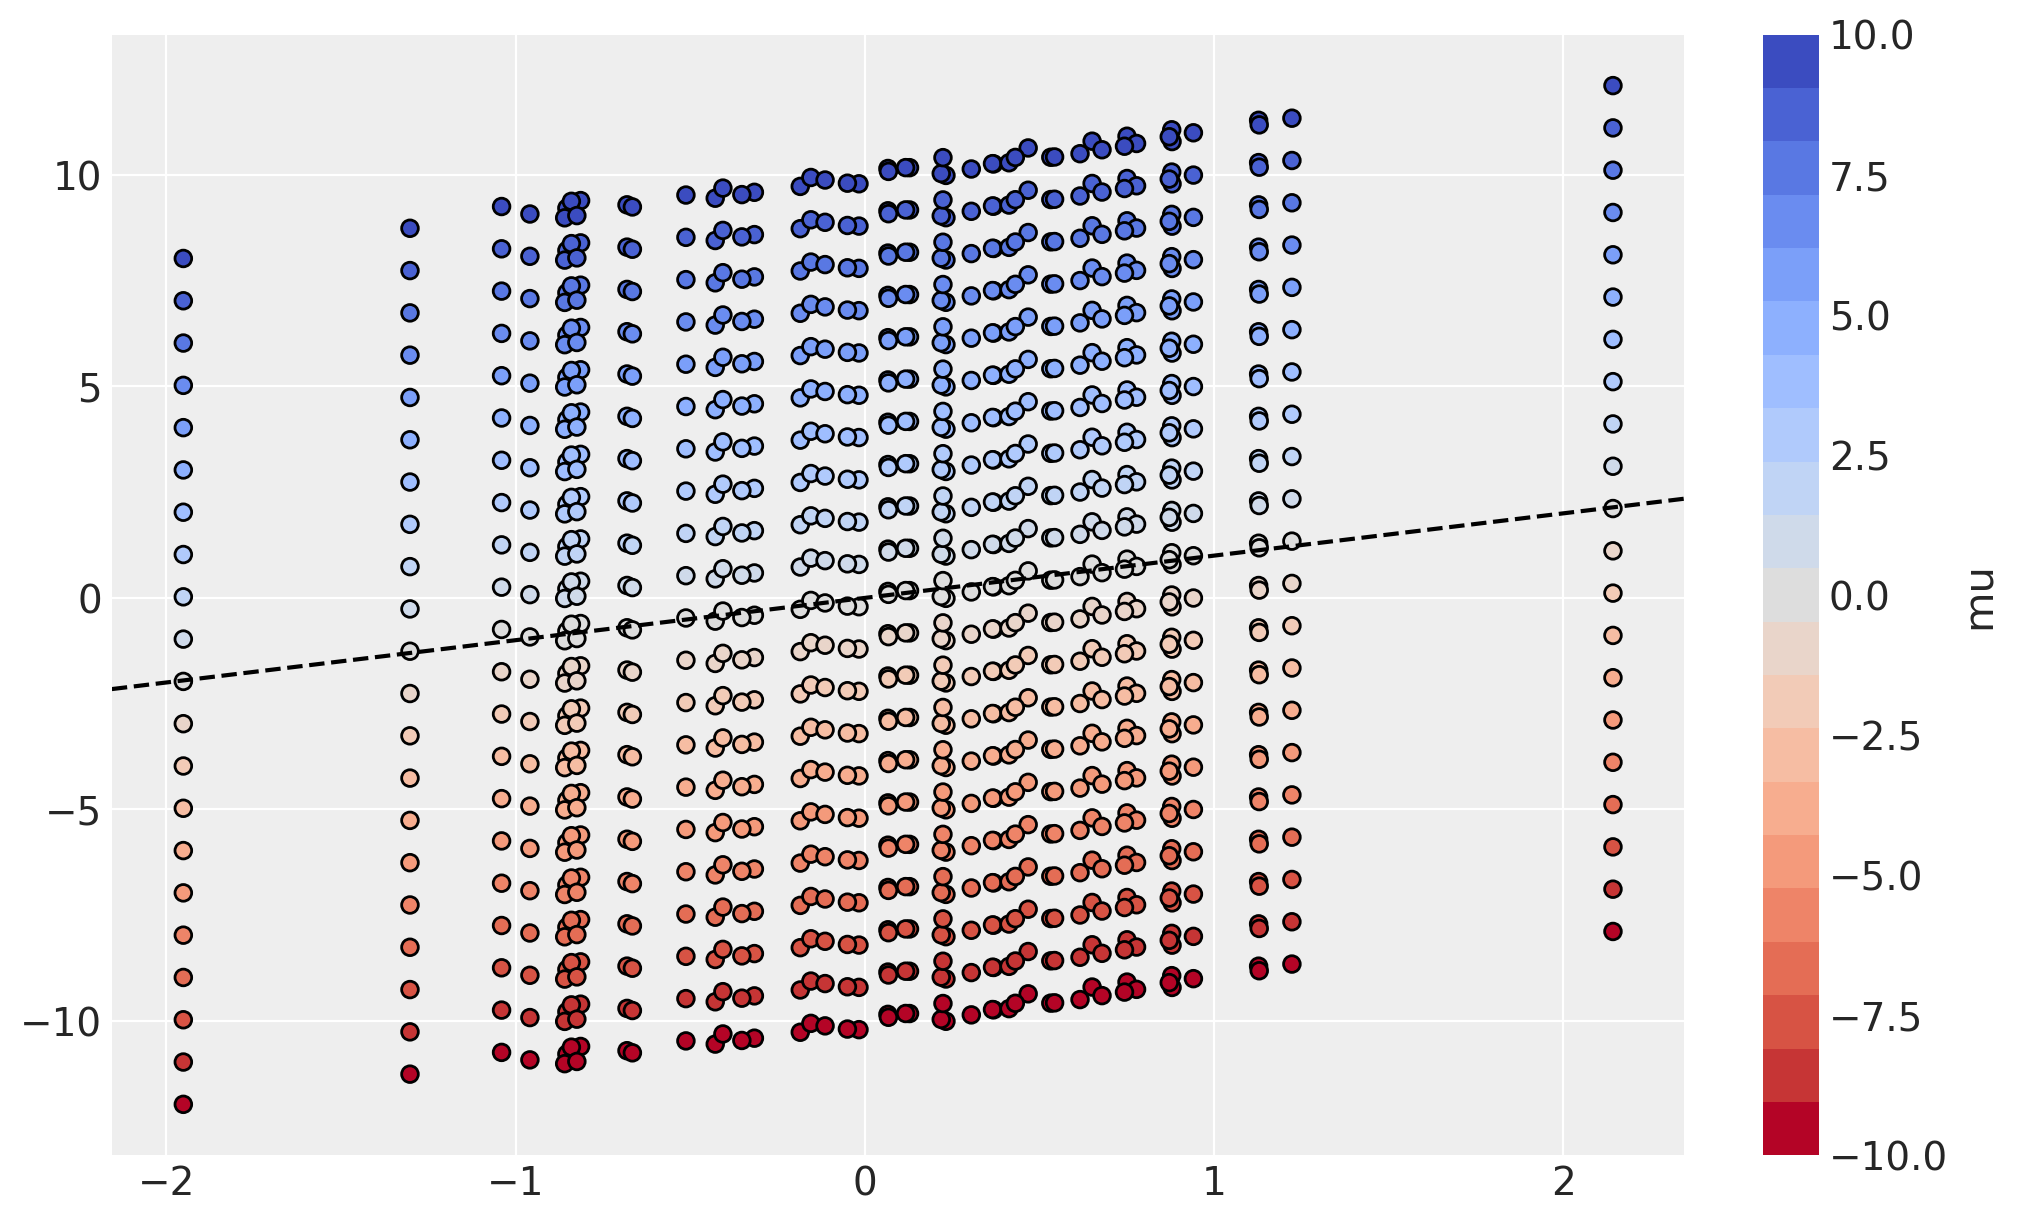

In [76]:
y_pred.sel(mu=0).mean(dim=("chain", "draw", "sigma"))

cmap = plt.get_cmap("coolwarm_r", k)

fig, ax = plt.subplots(figsize=(10, 6))

sc = None
for mu in mus:
    _y_pred_mean = y_pred.sel(mu=mu).mean(dim=("chain", "draw", "sigma"))
    sc = ax.scatter(
        y_true,
        _y_pred_mean,
        edgecolor="black",
        label=f"mu={mu:.2f}",
        c=[mu] * len(y_true),
        vmin=mus[0],
        vmax=mus[-1],
        cmap=cmap,
    )

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", label="mu")
ax.axline((0, 0), slope=1, color="black", linestyle="--")

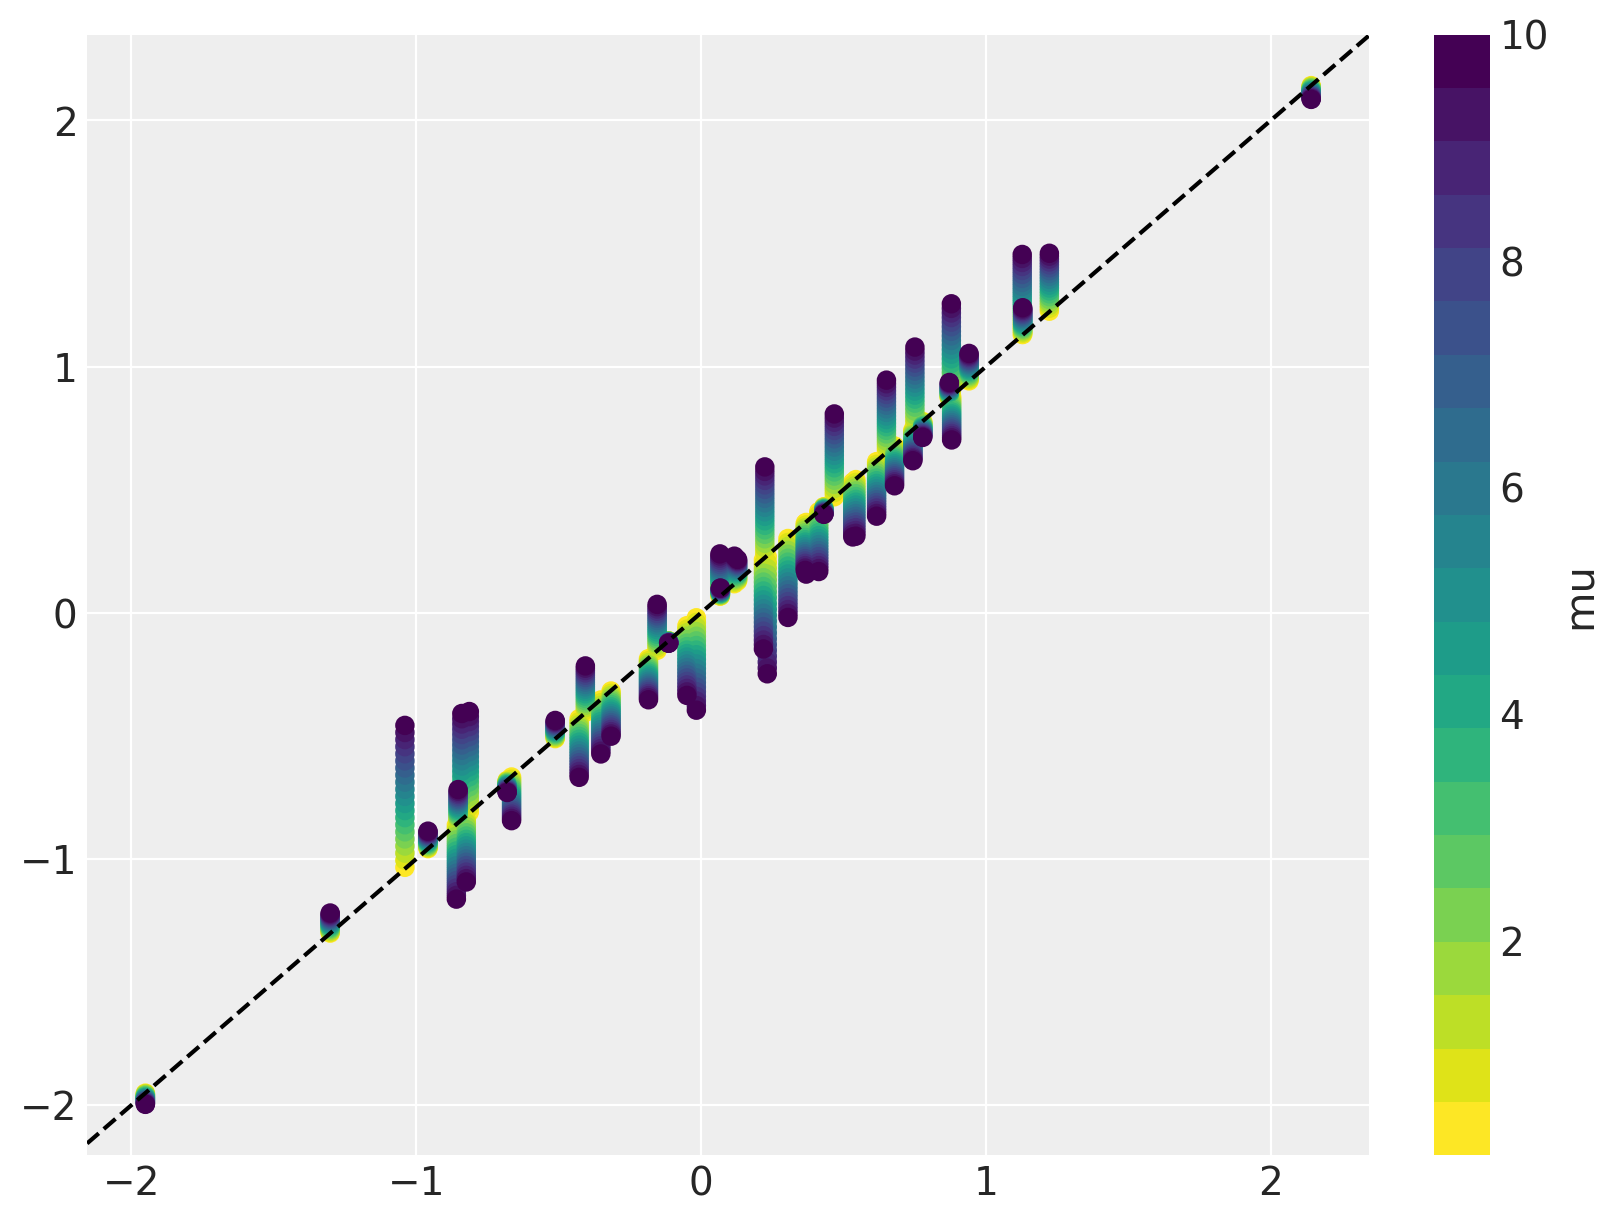

In [77]:
y_pred.sel(mu=0).mean(dim=("chain", "draw", "sigma"))

cmap = plt.get_cmap("viridis_r", k)

fig, ax = plt.subplots(figsize=(8, 6))

sc = None
for sigma in sigmas:
    _y_pred_mean = y_pred.sel(sigma=sigma).mean(dim=("chain", "draw", "mu"))
    sc = ax.scatter(
        y_true,
        _y_pred_mean,
        label=f"sigma={sigma:.2f}",
        c=[sigma] * len(y_true),
        vmin=sigmas[0],
        vmax=sigmas[-1],
        cmap=cmap,
    )

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", label="mu")
ax.axline((0, 0), slope=1, color="black", linestyle="--")

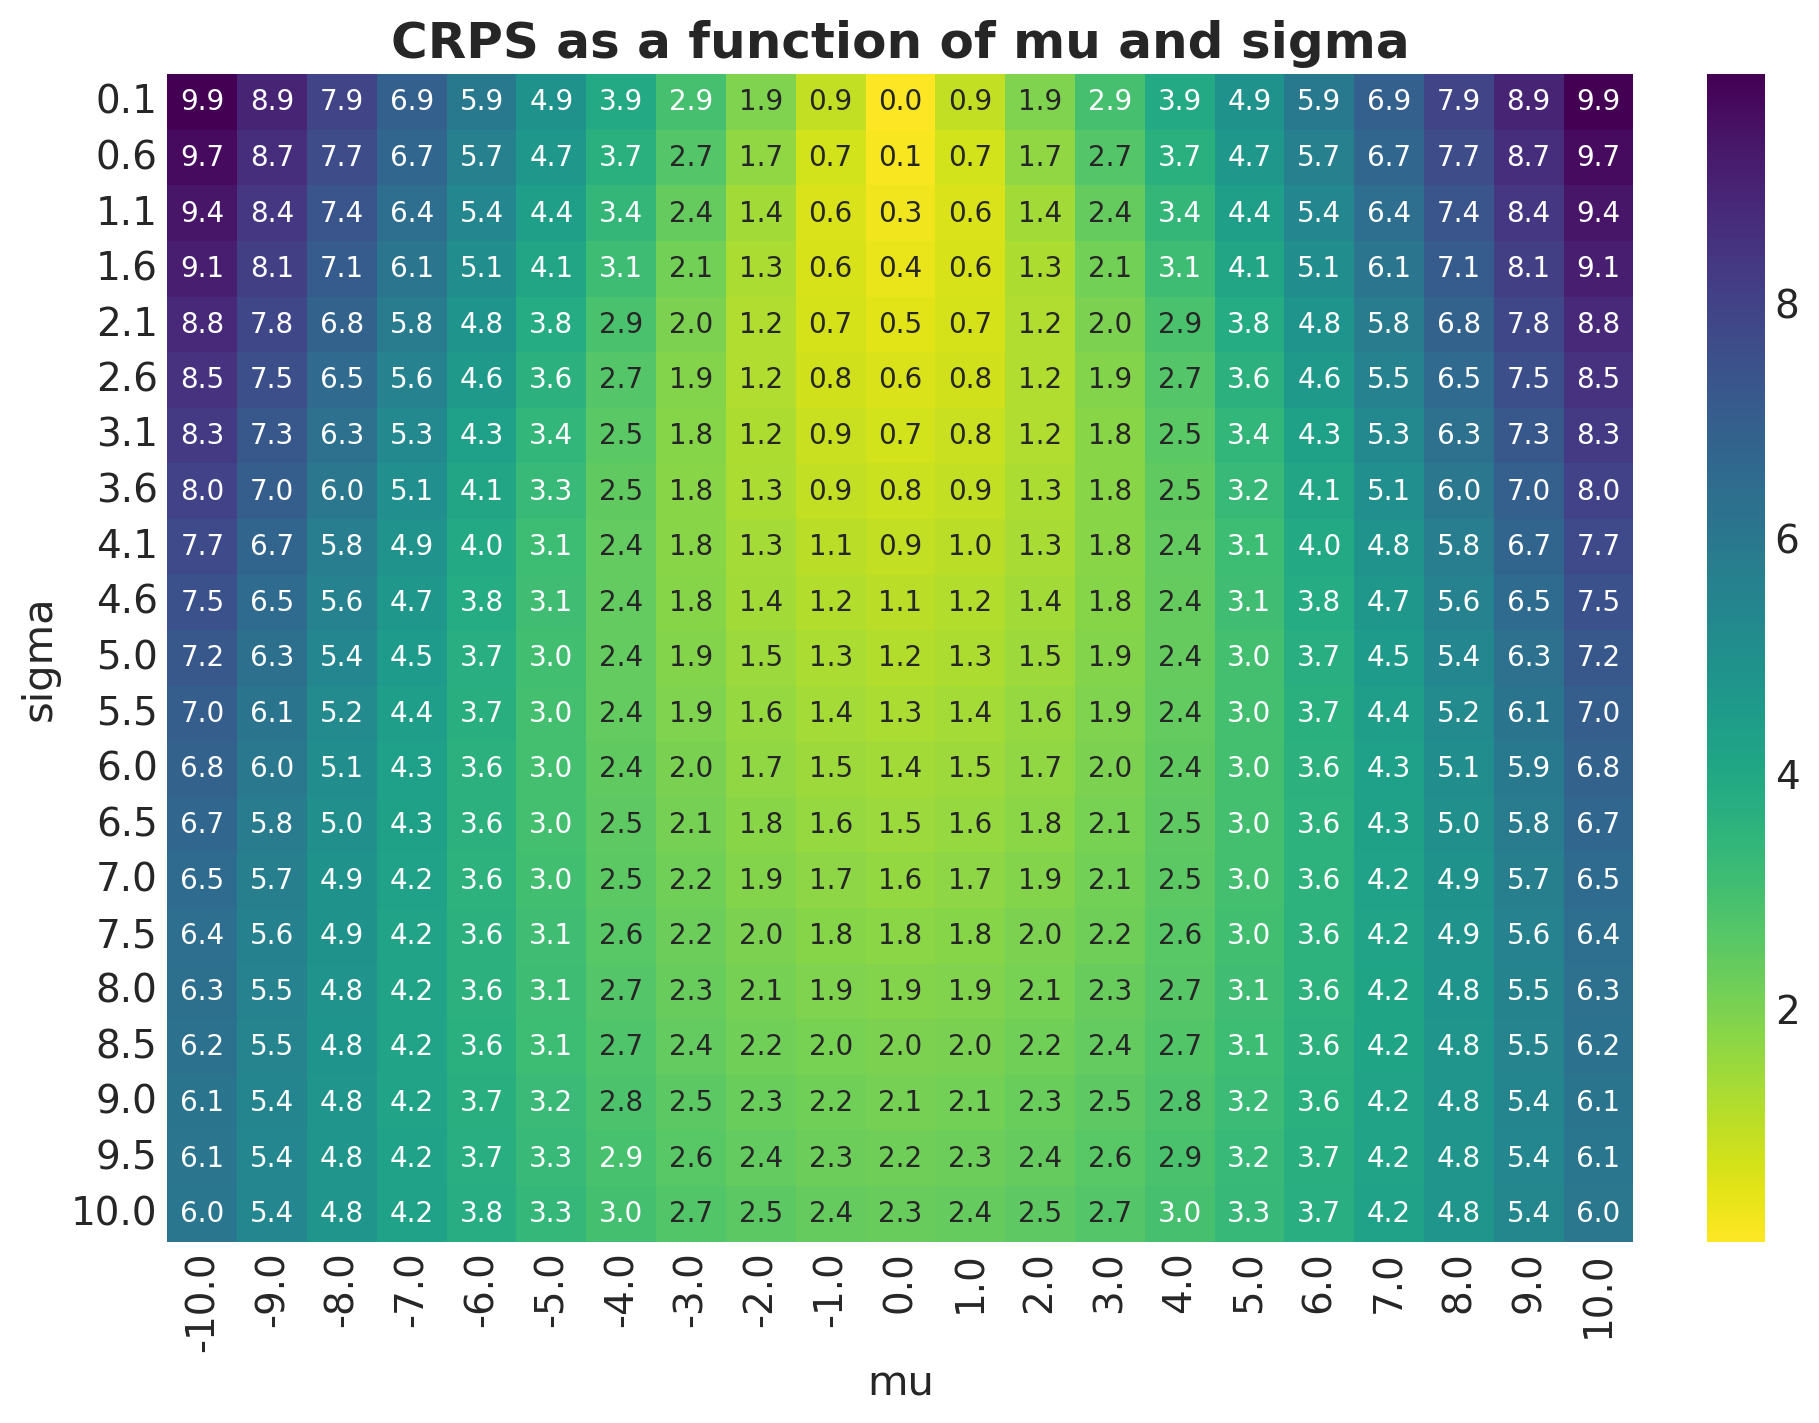

In [86]:
crps_values = np.empty((len(mus), len(sigmas)))
for i, sigma in enumerate(sigmas):
    for j, mu in enumerate(mus):
        crps_values[i, j] = crps(y_true, y_pred.sel(chain=0, sigma=sigma, mu=mu))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    crps_values,
    cmap="viridis_r",
    annot=True,
    fmt=".1f",
    xticklabels=[f"{mu:.1f}" for mu in mus],
    yticklabels=[f"{sigma:.1f}" for sigma in sigmas],
)
ax.set(xlabel="mu", ylabel="sigma")
ax.set_title("CRPS as a function of mu and sigma", fontsize=18, fontweight="bold");